In [1]:
import kagglehub

path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")


In [2]:
import pandas as pd
import os


tsv_file = os.path.join(path, 'StudentPerformanceFactors.csv')

df = pd.read_csv(tsv_file)

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# Study Hours

In [6]:
df[["Hours_Studied", "Exam_Score"]].corr()

,Hours_Studied,Exam_Score
Hours_Studied,1.000000,0.445455
Exam_Score,0.445455,1.000000


In [7]:
#There is a moderate positive correlation between Hours_Studied and Exam_Score (r = 0.445), meaning students who study more tend to score higher.
from scipy import stats

r, p = stats.pearsonr(df["Hours_Studied"], df["Exam_Score"])

print("Correlation:", r)
print("p-value:", p)

Correlation: 0.44545495407528185
p-value: 1.28635e-319


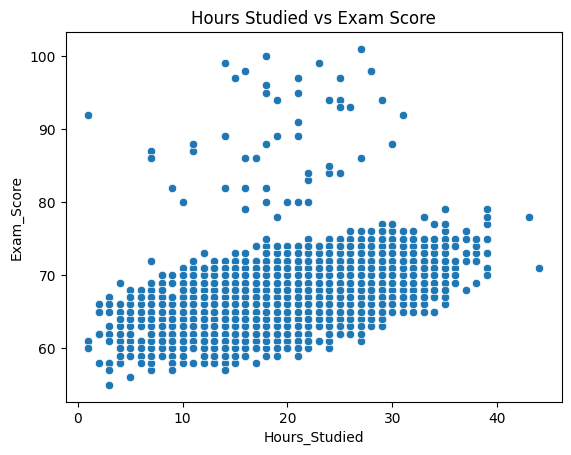

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Hours Studied vs Exam Score")
plt.show()


# Attendace

In [26]:
df[["Attendance", "Exam_Score"]].corr()

,Attendance,Exam_Score
Attendance,1.000000,0.581072
Exam_Score,0.581072,1.000000


In [10]:
from scipy import stats

r, p = stats.pearsonr(df["Attendance"], df["Exam_Score"])

print("Correlation:", r)
print("p-value:", p)

Correlation: 0.5810718633120641
p-value: 0.0


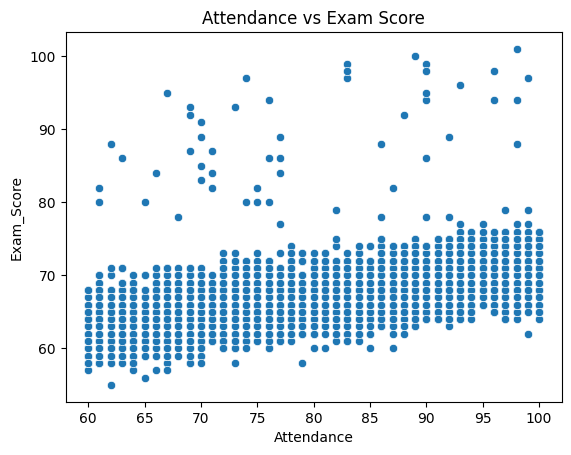

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Attendance", y="Exam_Score", data=df)
plt.title("Attendance vs Exam Score")
plt.show()

# Sleep Hours

In [12]:
df['Sleep_Hours'].describe()

count    6607.00000
mean        7.02906
std         1.46812
min         4.00000
25%         6.00000
50%         7.00000
75%         8.00000
max        10.00000
Name: Sleep_Hours, dtype: float64

<Axes: xlabel='Sleep_Hours', ylabel='Exam_Score'>

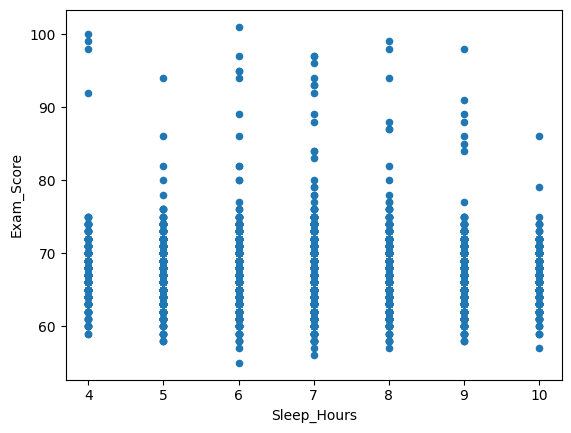

In [ ]:
df.plot(x='Sleep_Hours', y='Exam_Score', kind='scatter')

Observation: Students with 6–8 hours of sleep seem to have better scores.
Conclusion: Balanced sleep helps performance.

# Motivation

In [23]:
df['Motivation_Level'].value_counts()

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

<Axes: xlabel='Motivation_Level'>

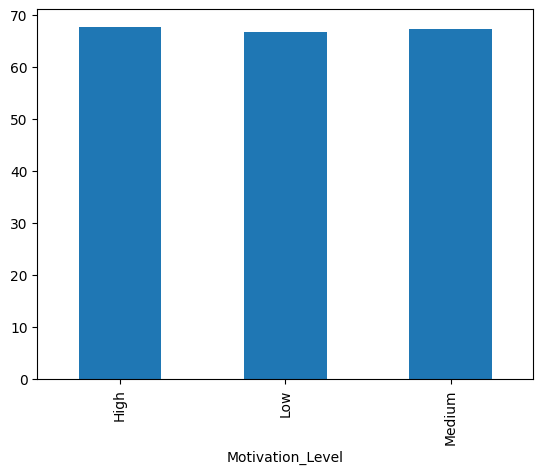

In [22]:
df.groupby('Motivation_Level')['Exam_Score'].mean().plot(kind='bar')

Observation: Higher motivation leads to higher exam scores.
Conclusion: Motivation has a strong effect.

# Tutoring Sessions

In [19]:
df['Tutoring_Sessions'].describe()

count    6607.000000
mean        1.493719
std         1.230570
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: Tutoring_Sessions, dtype: float64

<Axes: xlabel='Tutoring_Sessions', ylabel='Exam_Score'>

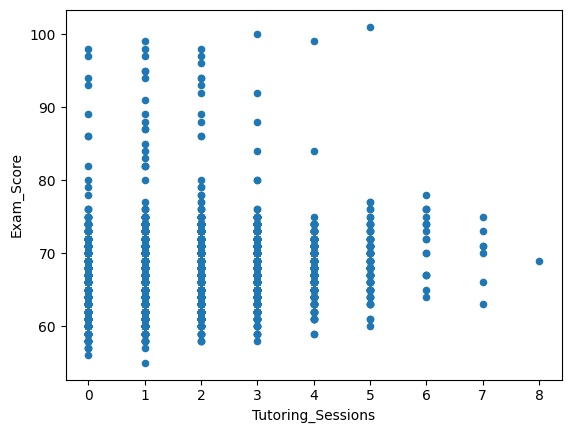

In [20]:
df.plot(x='Tutoring_Sessions', y='Exam_Score', kind='scatter')

Observation: More tutoring generally increases scores.
Conclusion: Tutoring is helpful but may level off.

# Parental Involvement

In [17]:
df.groupby('Parental_Involvement')['Exam_Score'].mean()

Parental_Involvement
High      68.092767
Low       66.358265
Medium    67.098156
Name: Exam_Score, dtype: float64

<Axes: xlabel='Parental_Involvement'>

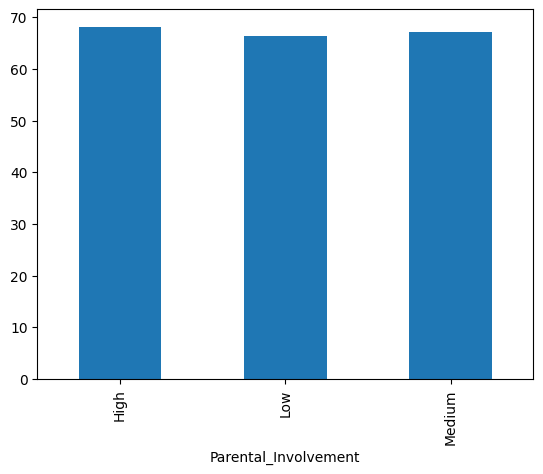

In [18]:
df.groupby('Parental_Involvement')['Exam_Score'].mean().plot(kind='bar')

Observation: Higher parental involvement leads to better scores.
Conclusion: Family support matters.

# School Type

In [15]:
df.groupby('School_Type')['Exam_Score'].mean()

School_Type
Private    67.287705
Public     67.212919
Name: Exam_Score, dtype: float64

<Axes: xlabel='School_Type'>

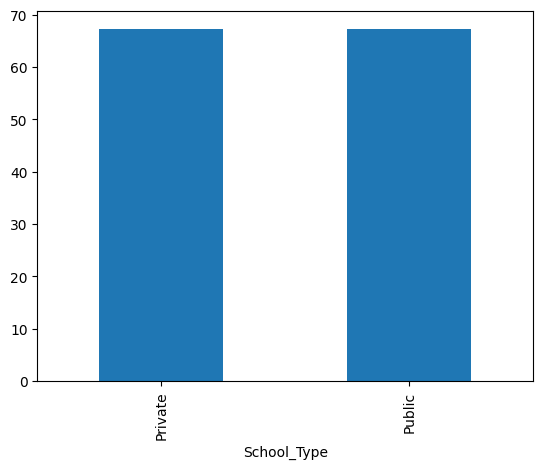

In [16]:
df.groupby('School_Type')['Exam_Score'].mean().plot(kind='bar')

Observation: The difference between school types is small.
Conclusion: School type is less important than other factors.

# Final Insights

1. Students who sleep 6–8 hours perform better.
2. Motivation strongly affects exam scores.
3. Tutoring helps improve performance.
4. Parental involvement increases success.
5. Students with support perform more consistently.
6. School type has a smaller effect.
7. Personal habits matter more than environment.